In [1]:
!pip install yfinance pandas_datareader matplotlib seaborn

In [2]:
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns

start_date = '2010-01-01'
end_date = '2026-04-14'

# 1. Fetch Yahoo Finance Data
print("Fetching Stock Data...")
bist = yf.download('XU100.IS', start=start_date, end=end_date)['Close']
sp500 = yf.download('^GSPC', start=start_date, end=end_date)['Close']

# 2. Fetch FRED-MD Macro Data
print("Fetching FRED Macro Data...")
cpi = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)
unrate = web.DataReader('UNRATE', 'fred', start_date, end_date)
fedfunds = web.DataReader('FEDFUNDS', 'fred', start_date, end_date)
indpro = web.DataReader('INDPRO', 'fred', start_date, end_date)

# 3. Merge Everything into one DataFrame
df = pd.concat([bist, sp500, cpi, unrate, fedfunds, indpro], axis=1)
df.columns = ['BIST_Close', 'SP500_Close', 'CPI', 'Unemployment', 'Interest_Rate', 'Ind_Production']

# 4. Clean the data (forward-fill missing dates like weekends/holidays)
df.fillna(method='ffill', inplace=True)
df.dropna(inplace=True)

print("Data successfully loaded and merged! Here are the first 5 rows:")
display(df.head())

Fetching Stock Data...


/tmp/ipykernel_9189/979699910.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bist = yf.download('XU100.IS', start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_9189/979699910.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed


Fetching FRED Macro Data...
Data successfully loaded and merged! Here are the first 5 rows:


/tmp/ipykernel_9189/979699910.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,BIST_Close,SP500_Close,CPI,Unemployment,Interest_Rate,Ind_Production
2010-01-04,533.679199,1132.989990,217.488,9.8,0.11,89.3426
2010-01-05,541.148132,1136.520020,217.488,9.8,0.11,89.3426
2010-01-06,545.471130,1137.140015,217.488,9.8,0.11,89.3426
2010-01-07,549.726074,1141.689941,217.488,9.8,0.11,89.3426
2010-01-08,547.976074,1144.979980,217.488,9.8,0.11,89.3426


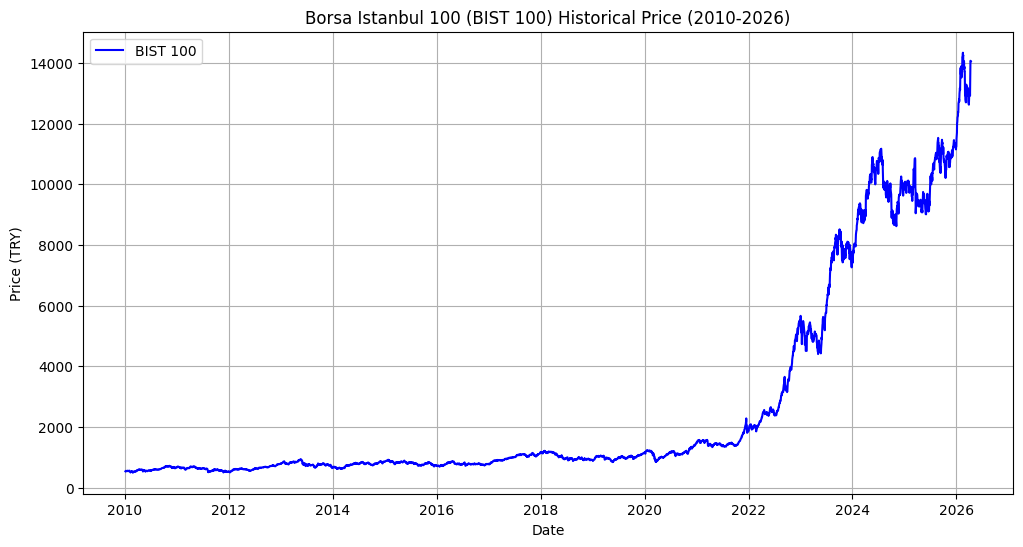

In [3]:
plt.figure(figsize=(12, 6))

# Plot the BIST 100 column against the Date index
plt.plot(df.index, df['BIST_Close'], color='blue', label='BIST 100')

plt.title('Borsa Istanbul 100 (BIST 100) Historical Price (2010-2026)')
plt.xlabel('Date')
plt.ylabel('Price (TRY)')
plt.grid(True)
plt.legend()

# Export as .png
plt.savefig('bist_price_history.png', bbox_inches='tight')
plt.show()

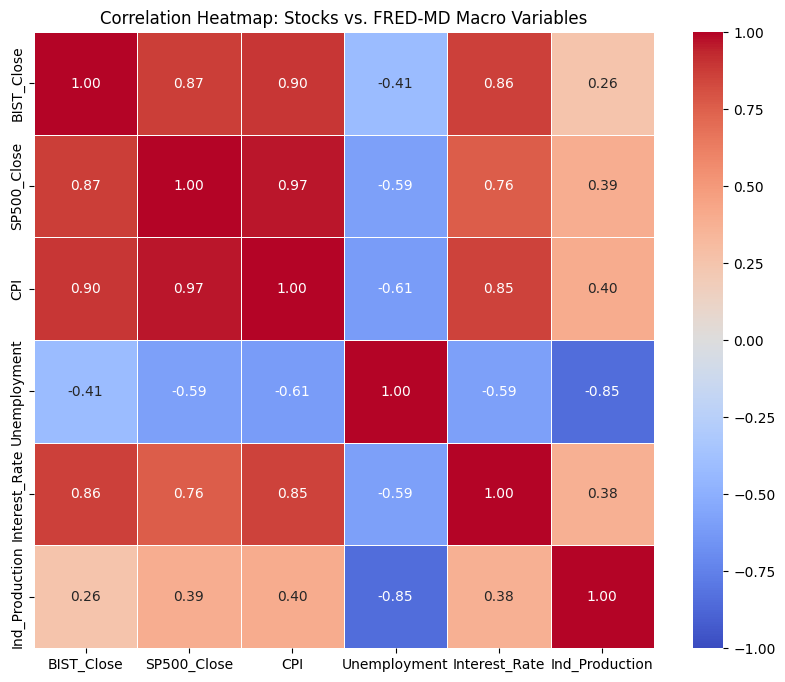

In [4]:
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix
corr_matrix = df.corr()

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Correlation Heatmap: Stocks vs. FRED-MD Macro Variables')

# Export as .png
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()